## Addition Interp
**"How do small transformers trained on addition data learn to add?"**

authored by : vorrjjard

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import torch as t
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt

import transformer_lens

from transformer_lens import HookedTransformer, ActivationCache, HookedTransformerConfig
from transformer_lens.train import HookedTransformerTrainConfig, train

import typing
from typing import Literal, List

from dataclasses import dataclass

import numpy as np

import plotly.express as px

/Users/rubena.saulog/Developer/fib-interp-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import (
    vocab,
    vocab_inv,
    pad,
    generate_sample,
    dataConfig,
    data_cfg,
    samples_tensor,
    SumDataset,
    ds,
    train_ds,
    val_ds,
    train_dl,
    val_dl,
    create_model,
)

In [3]:
DEVICE = 'cpu'
print(DEVICE)

cpu


Let's define a small vocabulary for our project. Hence, our `d_vocab = 10` 

##### 2. Model Configuration / Training

In [4]:
model = create_model(
    num_digits=4,
    seed=0,
    d_model=48,
    d_head=24,
    n_layers=2,
    n_heads=3,
    normalization_type="LN",
    d_mlp=None,
    device=DEVICE,
)

In [5]:
opt = t.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2, betas=(0.9, 0.98))

##### Training Stuff 

In [6]:
ANS = slice(9, 13)

def masked_loss(logits, tokens):
    logp = logits[:, ANS].log_softmax(-1)
    tgt  = tokens[:, 10:14]
    return -logp.gather(-1, tgt.unsqueeze(-1)).mean()

@t.no_grad()
def accuracy_and_loss(model, tokens, bs=1024):
    digit, full, n = 0, 0, 0
    for i in range(0, len(tokens), bs):
        b = tokens[i:i+bs]['tokens'].to(DEVICE)
        logits = model(b)
        loss = masked_loss(logits, b)

        pred = logits[:, ANS].argmax(-1)
        eq = (pred == b[:, 10:14])
        digit += eq.sum().item(); full += eq.all(-1).sum().item(); n += len(b)
    return digit / (n*4), full / n, loss

In [7]:
EPOCHS = 100
losses = []

for epoch in range(EPOCHS):
    model.train()
    for batch in train_dl:
        tokens = batch["tokens"].to(DEVICE)
        loss = masked_loss(model(tokens), tokens)
        loss.backward(); opt.step(); opt.zero_grad()
    model.eval()
    da, fa, test_loss = accuracy_and_loss(model, val_ds)
    losses.append(f'{test_loss.item():.4f}')
    print(f"epoch {epoch:2d} | loss {loss.item():.4f} | test digit {da:.3f} full {fa:.3f} | test loss : {test_loss.item():.4f}")

t.save(model.state_dict(), "../models/sum_model.pt")

epoch  0 | loss 1.7704 | test digit 0.317 full 0.001 | test loss : 1.7660
epoch  1 | loss 1.7360 | test digit 0.326 full 0.002 | test loss : 1.7373
epoch  2 | loss 1.7274 | test digit 0.326 full 0.001 | test loss : 1.7345
epoch  3 | loss 1.7314 | test digit 0.326 full 0.001 | test loss : 1.7334
epoch  4 | loss 1.2032 | test digit 0.544 full 0.011 | test loss : 1.1984
epoch  5 | loss 1.1515 | test digit 0.552 full 0.011 | test loss : 1.1565
epoch  6 | loss 1.0658 | test digit 0.592 full 0.028 | test loss : 1.0626
epoch  7 | loss 0.7936 | test digit 0.687 full 0.068 | test loss : 0.7764
epoch  8 | loss 0.6256 | test digit 0.759 full 0.180 | test loss : 0.6438
epoch  9 | loss 0.2634 | test digit 0.878 full 0.530 | test loss : 0.2851
epoch 10 | loss 0.0819 | test digit 0.991 full 0.965 | test loss : 0.0741
epoch 11 | loss 0.0411 | test digit 0.991 full 0.965 | test loss : 0.0392
epoch 12 | loss 0.0382 | test digit 0.991 full 0.965 | test loss : 0.0410
epoch 13 | loss 0.0091 | test digit 1.

In [8]:
losses = [float(x) for x in losses]

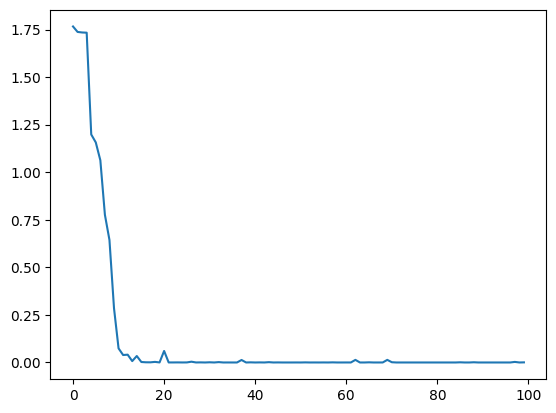

In [9]:
epochs = np.arange(0, len(losses)).tolist()

plt.plot(epochs, losses)
plt.show()

Training

#### 3. Actual Interp

In [10]:
tokens = samples_tensor[2, :]
tokens

tensor([ 2,  3,  0,  6, 11,  3,  3,  2,  0, 10,  6,  2,  6,  5])

In [11]:
token_labels = [vocab_inv[token.item()] for token in tokens]

logits, cache = model.run_with_cache(tokens.to(DEVICE))

In [12]:
attn_scores_0 = cache['blocks.0.attn.hook_pattern']
attn_scores_1 = cache['blocks.1.attn.hook_pattern']

attn_scores = t.cat([attn_scores_0, attn_scores_1], dim=0)

In [13]:
sum_scores = attn_scores[:, :, -5:-1, :]

pos_labels = [f"[{i}]{label}" for i, label in enumerate(token_labels)]

px.imshow(
    sum_scores.detach().cpu().numpy(),
    facet_col=0,
    facet_row=1,
    labels=dict(x='Key', y='Query'),
    x=pos_labels,
    y=pos_labels[-5:-1],
    zmin=0,
    zmax=1,
    color_continuous_scale=[[0, 'black'], [1, '#fde725']],
)